# PINN-MLP Diagnostic Visualisations
### ScreenAnt — Finger Localisation · CSE3000 · TU Delft · 2026

This notebook runs **five diagnostic visualisations** to inform architecture decisions for the PINN-MLP localisation model.

| # | Visualisation | Decision it informs |
|---|---|---|
| 1 | Physics loss landscape | Is $\mathcal{L}_{phys}$ a reliable gradient signal? |
| 2 | Gradient cosine similarity | Does physics help or fight position loss? |
| 3 | PCA of signal space | How discriminative is the raw array response? |
| 4 | t-SNE of signal space | Nonlinear discriminability of signal space |
| 5 | Re(y) / Im(y) as 7×7 grids | Is spatial structure present → CNN justified? |

**Run all cells top-to-bottom.** Adjust `SYS_PATH` in Cell 2 if your scripts are in a different directory.

## Setup

In [2]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.ndimage import uniform_filter1d

import sys, os

# Point to the project root (one level up from notebooks/)
PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname(''), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Now use absolute imports from project root
from core.finger import *
from core.array import *
from core.trajectory import *
from localisation import *
from data.generate import *

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
print(f'Array: {Sx}x{Sy} = {S} elements  |  f0={f0/1e9:.0f} GHz  '
      f'|  lambda={lam*1e3:.2f} mm  |  de={de*1e3:.2f} mm')

Array: 7x7 = 49 elements  |  f0=28 GHz  |  lambda=10.71 mm  |  de=5.36 mm


## Generate Data

Builds the array, coupling matrix, and a set of test trajectories used throughout all diagnostics.

In [3]:
# Build array and coupling
array_pos = build_array(Sx, Sy, de)
C = build_coupling_matrix(array_pos, k, epsilon)

def make_traj_and_signal(traj_fn, seed=0, **kwargs):
    """Generate one trajectory and its array responses."""
    traj = traj_fn(N, dt, Sx, Sy, de, **kwargs)
    Y, _, _ = simulate_extended(
        traj, array_pos, k, sigma_f_phys,
        a_x, a_y, beta_min, phi_max, C, sigma_n2
    )
    return traj, Y

traj_lin, Y_lin = make_traj_and_signal(trajectory_linear)
traj_sin, Y_sin = make_traj_and_signal(trajectory_sinusoidal)
traj_rnd, Y_rnd = make_traj_and_signal(trajectory_random_walk, seed=7)

# Stack all trajectories for PCA / t-SNE
Y_all   = np.concatenate([Y_lin, Y_sin, Y_rnd], axis=0)    # (3N, S)
P_all   = np.concatenate([traj_lin[:,:2],
                           traj_sin[:,:2],
                           traj_rnd[:,:2]], axis=0)          # (3N, 2)
labels  = np.concatenate([np.zeros(N), np.ones(N), 2*np.ones(N)])  # traj type

print(f'Y_all shape: {Y_all.shape}  (snapshots x elements)')
print(f'P_all shape: {P_all.shape}  (snapshots x 2D position)')

Y_all shape: (600, 49)  (snapshots x elements)
P_all shape: (600, 2)  (snapshots x 2D position)


In [4]:
def forward_model(pos_2d):
    """
    Extended forward model template at a 2D candidate position.
    Returns C·[Gamma(q) ⊙ a(q)]  shape (S,) complex.
    """
    pos3d = np.array([pos_2d[0], pos_2d[1], z_f0])
    rho   = finger_footprint(array_pos, pos3d, a_x, a_y)
    gamma = complex_transmission(rho, beta_min, phi_max)
    a_sv  = extended_steering_vector(
        array_pos, pos3d, k, sigma_f_phys, a_x, a_y, rho=rho
    )
    return C @ (gamma * a_sv)

# Quick test
t0 = forward_model([0.0, 0.0])
print(f'Forward model output shape: {t0.shape}  dtype: {t0.dtype}')

Forward model output shape: (49,)  dtype: complex128


---
## 1 · Physics Loss Landscape

**What it shows.** For a fixed observed snapshot $\mathbf{y}_{obs}$, compute the physics loss $\mathcal{L}_{phys}(\mathbf{q})$ at every point on a 2D grid over the screen:

$$\mathcal{L}_{phys}(\mathbf{q}) = \frac{\|\mathbf{t}(\mathbf{q}) - \mathbf{y}_{obs}\|^2}{\bar{y}}$$

**What to look for.**
- **Sharp single minimum at the true position** → physics loss is a reliable gradient signal. The PINN will benefit from it.
- **Flat landscape** → physics loss provides almost no gradient information. This explains PINN performing similar to MLP.
- **Multiple local minima** → gradient descent on physics loss alone will get trapped. Curriculum learning (start from position loss, gradually add physics) is then essential.

Three snapshots are shown: finger at the **centre**, at a **corner**, and at a **mid-edge** position.

In [6]:
grid_pts = 60
x_min, x_max, y_min, y_max = screen_bounds(Sx, Sy, de)
gx = np.linspace(x_min, x_max, grid_pts)
gy = np.linspace(y_min, y_max, grid_pts)
GX, GY = np.meshgrid(gx, gy)

def physics_landscape(y_obs):
    """Compute L_phys over the full grid for one observed snapshot."""
    y_scale = np.mean(np.abs(y_obs)) + 1e-12
    L = np.zeros((grid_pts, grid_pts))
    for i, yy in enumerate(gy):
        for j, xx in enumerate(gx):
            t_q  = forward_model([xx, yy])
            res  = (t_q - y_obs) / y_scale
            L[i, j] = np.real(res.conj() @ res)
    return L

# Three test positions and corresponding snapshots
test_positions = [
    ('Centre',    np.array([0.0,        0.0        ])),
    ('Corner',    np.array([x_min*0.7,  y_min*0.7  ])),
    ('Mid-edge',  np.array([x_max*0.7,  0.0        ])),
]

print('Computing physics loss landscapes (this takes ~30s)...')
landscapes = []
for name, pos in test_positions:
    y_obs = forward_model(pos)   # noiseless for clean landscape
    L     = physics_landscape(y_obs)
    landscapes.append((name, pos, L))
    print(f'  {name}: min={L.min():.4f}  max={L.max():.4f}')
print('Done.')

Computing physics loss landscapes (this takes ~30s)...
  Centre: min=4.1196  max=203.8070
  Corner: min=0.5295  max=312.7513
  Mid-edge: min=2.3772  max=273.6244
Done.


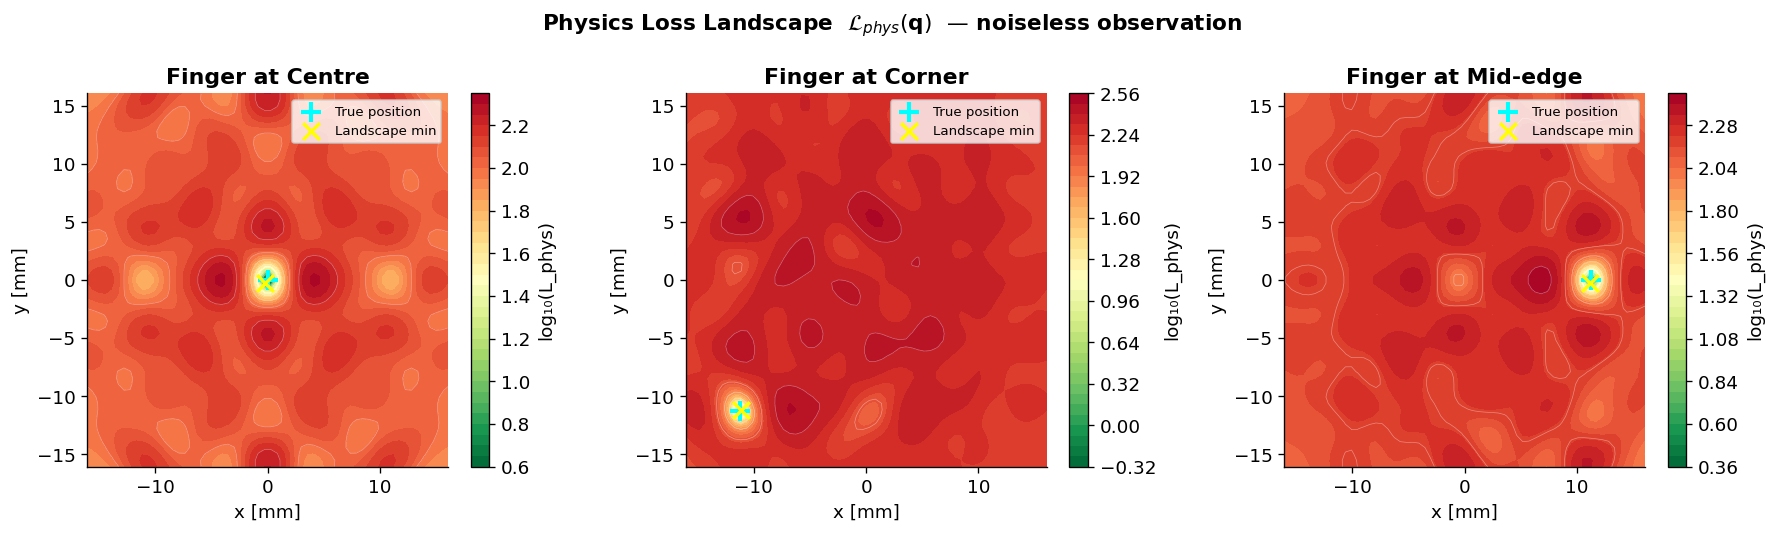

Saved: diag_1_physics_landscape.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (name, pos, L) in zip(axes, landscapes):
    # Log scale so small values near minimum are visible
    L_log = np.log10(L + 1e-10)
    im = ax.contourf(GX*1e3, GY*1e3, L_log, levels=40, cmap='RdYlGn_r')
    ax.contour( GX*1e3, GY*1e3, L_log, levels=10,
                colors='white', linewidths=0.4, alpha=0.4)
    # True position
    ax.scatter(*pos*1e3, s=150, color='cyan', marker='+',
               linewidths=2.5, zorder=5, label='True position')
    # Minimum of landscape
    min_idx = np.unravel_index(np.argmin(L), L.shape)
    ax.scatter(gx[min_idx[1]]*1e3, gy[min_idx[0]]*1e3,
               s=100, color='yellow', marker='x',
               linewidths=2, zorder=5, label='Landscape min')
    ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
    ax.set_title(f'Finger at {name}', fontweight='bold')
    ax.legend(fontsize=8)
    plt.colorbar(im, ax=ax, label='log₁₀(L_phys)')

plt.suptitle('Physics Loss Landscape  $\\mathcal{L}_{phys}(\\mathbf{q})$  '
             '— noiseless observation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('diag_1_physics_landscape.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: diag_1_physics_landscape.png')

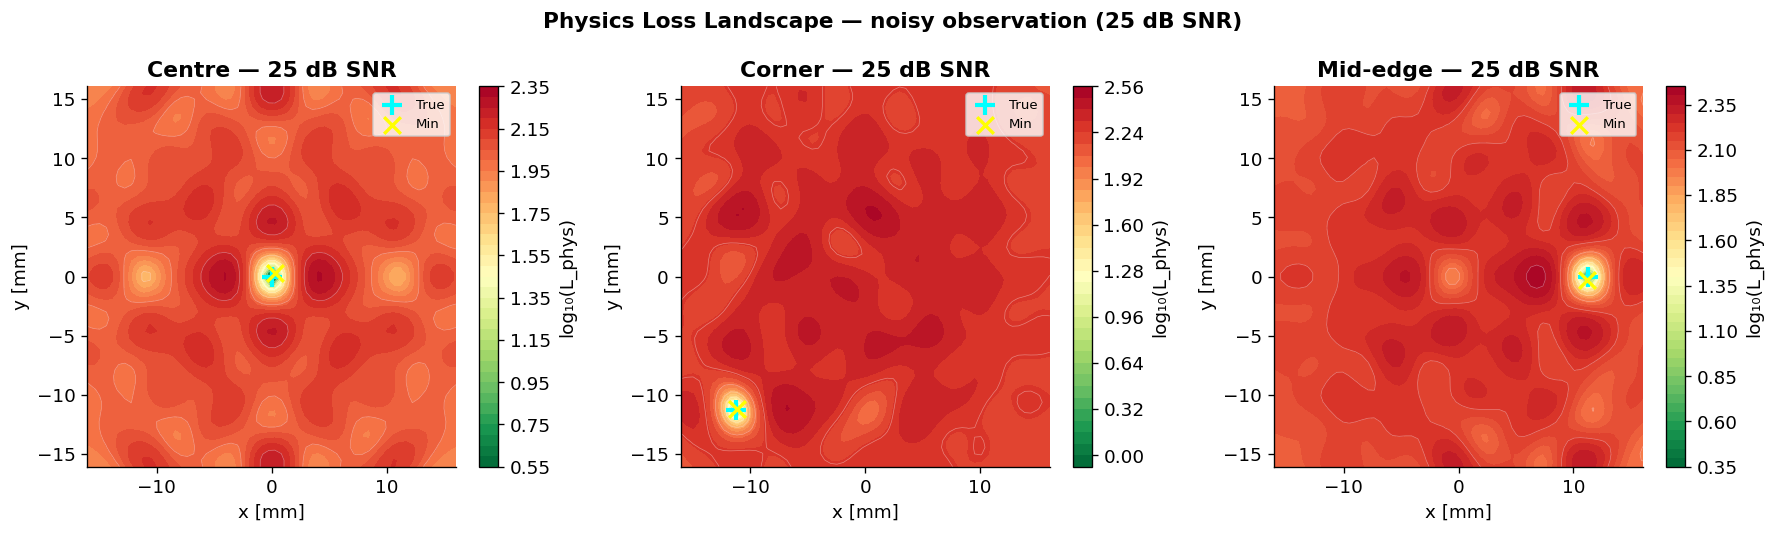

Saved: diag_1b_physics_landscape_noisy.png


In [8]:
# Repeat with noisy observations to see how noise affects the landscape
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (name, pos) in zip(axes, test_positions):
    # Noisy snapshot at 25 dB SNR
    y_clean = forward_model(pos)
    P_sig   = np.mean(np.abs(y_clean)**2)
    sn2_25  = P_sig / (10**(25/10))
    noise   = (np.random.randn(S) + 1j*np.random.randn(S)) * np.sqrt(sn2_25/2)
    y_noisy = y_clean + noise

    L     = physics_landscape(y_noisy)
    L_log = np.log10(L + 1e-10)
    im = ax.contourf(GX*1e3, GY*1e3, L_log, levels=40, cmap='RdYlGn_r')
    ax.contour( GX*1e3, GY*1e3, L_log, levels=10,
                colors='white', linewidths=0.4, alpha=0.4)
    ax.scatter(*pos*1e3, s=150, color='cyan', marker='+',
               linewidths=2.5, zorder=5, label='True')
    min_idx = np.unravel_index(np.argmin(L), L.shape)
    ax.scatter(gx[min_idx[1]]*1e3, gy[min_idx[0]]*1e3,
               s=100, color='yellow', marker='x',
               linewidths=2, zorder=5, label='Min')
    ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
    ax.set_title(f'{name} — 25 dB SNR', fontweight='bold')
    ax.legend(fontsize=8)
    plt.colorbar(im, ax=ax, label='log₁₀(L_phys)')

plt.suptitle('Physics Loss Landscape — noisy observation (25 dB SNR)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('diag_1b_physics_landscape_noisy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: diag_1b_physics_landscape_noisy.png')

---
## 2 · Gradient Cosine Similarity

**What it shows.** For a trained network, at each test snapshot compute the cosine similarity between the position loss gradient and the physics loss gradient with respect to the network's predicted position:

$$\cos\theta = \frac{\nabla_{\hat{\mathbf{p}}}\mathcal{L}_{pos} \cdot \nabla_{\hat{\mathbf{p}}}\mathcal{L}_{phys}}{\|\nabla\mathcal{L}_{pos}\|\,\|\nabla\mathcal{L}_{phys}\|}$$

**What to look for.**
- **cos θ > 0** (positive, green) → the two gradients point in the same direction. Physics loss is helping. PINN is working as intended.
- **cos θ < 0** (negative, red) → gradient conflict. Physics is pulling the update in the wrong direction. This is the root cause of PINN performing worse than plain MLP.
- **cos θ ≈ 0** → physics gradient is orthogonal to position gradient — physics loss is irrelevant at that snapshot.

We simulate this without a fully trained network by evaluating at the **true position** (representing what a well-trained network should predict) and at **perturbed positions** (representing typical network errors).

In [9]:
def grad_pos(pred_pos, true_pos):
    """Gradient of position MSE w.r.t. predicted position."""
    return 2 * (pred_pos - true_pos)   # shape (2,)

def grad_phys(pred_pos, y_obs, h=1e-5):
    """
    Gradient of physics loss w.r.t. predicted position,
    via central finite differences.
    """
    y_scale = np.mean(np.abs(y_obs)) + 1e-12
    grads = np.zeros(2)
    for dim in range(2):
        pp = pred_pos.copy(); pp[dim] += h
        pm = pred_pos.copy(); pm[dim] -= h
        rp = (forward_model(pp) - y_obs) / y_scale
        rm = (forward_model(pm) - y_obs) / y_scale
        Lp = np.real(rp.conj() @ rp)
        Lm = np.real(rm.conj() @ rm)
        grads[dim] = (Lp - Lm) / (2*h)
    return grads

def cosine_sim(g1, g2):
    n1, n2 = np.linalg.norm(g1), np.linalg.norm(g2)
    if n1 < 1e-12 or n2 < 1e-12:
        return 0.0
    return float(g1 @ g2 / (n1 * n2))

print('Gradient functions defined.')

Gradient functions defined.


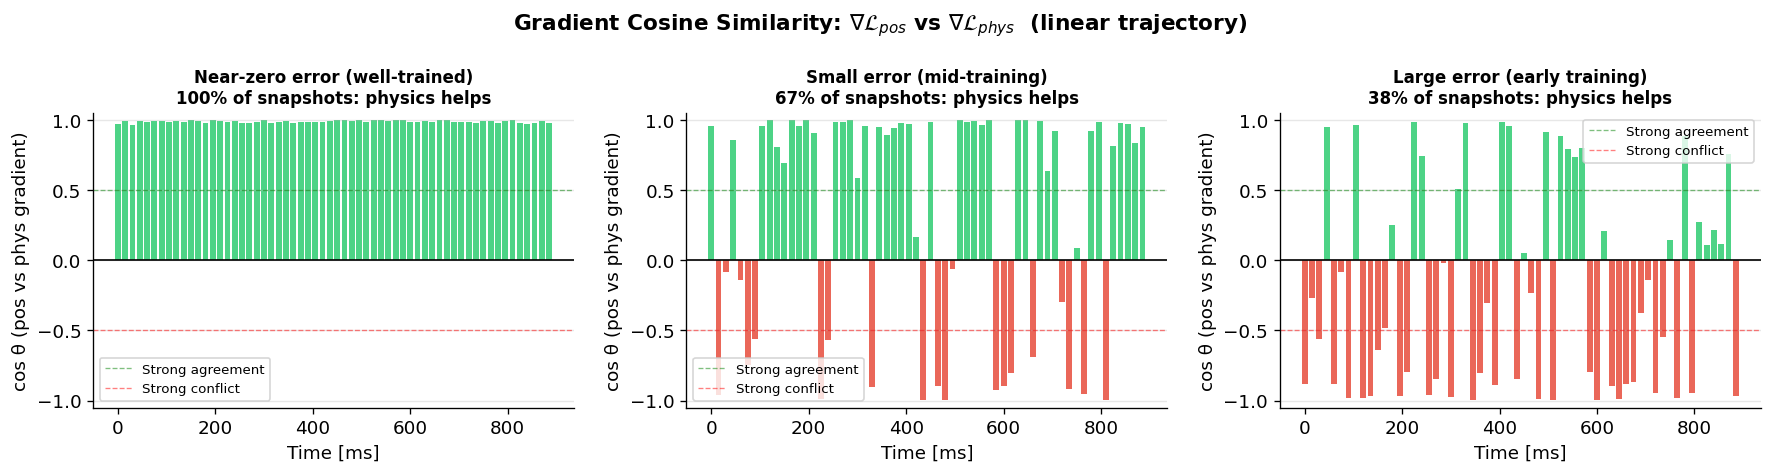

Saved: diag_2_gradient_cosine.png


In [10]:
# Evaluate cosine similarity at 60 snapshots along the linear trajectory
n_snapshots = 60
step = N // n_snapshots
indices = np.arange(0, N, step)[:n_snapshots]

# Three error levels to simulate different training stages
error_levels = [
    ('Near-zero error (well-trained)',   0.5e-3),   # 0.5 mm error
    ('Small error (mid-training)',       3.0e-3),   # 3 mm error
    ('Large error (early training)',     10.0e-3),  # 10 mm error
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (label, error_mag) in zip(axes, error_levels):
    cos_sims = []
    for idx in indices:
        true_pos = traj_lin[idx, :2]           # true 2D position
        y_obs    = Y_lin[idx]                   # observed signal
        # Simulated prediction: true position + random error
        pred_pos = true_pos + np.random.randn(2) * error_mag
        g_pos  = grad_pos(pred_pos, true_pos)
        g_phys = grad_phys(pred_pos, y_obs)
        cos_sims.append(cosine_sim(g_pos, g_phys))

    cos_sims = np.array(cos_sims)
    t_axis   = indices * dt * 1e3   # ms

    # Colour by sign
    colors = ['#2ECC71' if c > 0 else '#E74C3C' for c in cos_sims]
    ax.bar(t_axis, cos_sims, width=dt*1e3*step*0.8,
           color=colors, alpha=0.85)
    ax.axhline(0, color='black', linewidth=1)
    ax.axhline( 0.5, color='green', linewidth=0.8,
               linestyle='--', alpha=0.5, label='Strong agreement')
    ax.axhline(-0.5, color='red',   linewidth=0.8,
               linestyle='--', alpha=0.5, label='Strong conflict')
    frac_pos = np.mean(cos_sims > 0)
    ax.set_title(f'{label}\n{frac_pos*100:.0f}% of snapshots: physics helps',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Time [ms]')
    ax.set_ylabel('cos θ (pos vs phys gradient)')
    ax.set_ylim(-1.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Gradient Cosine Similarity: $\\nabla\\mathcal{L}_{pos}$ '
             'vs $\\nabla\\mathcal{L}_{phys}$  (linear trajectory)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('diag_2_gradient_cosine.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: diag_2_gradient_cosine.png')

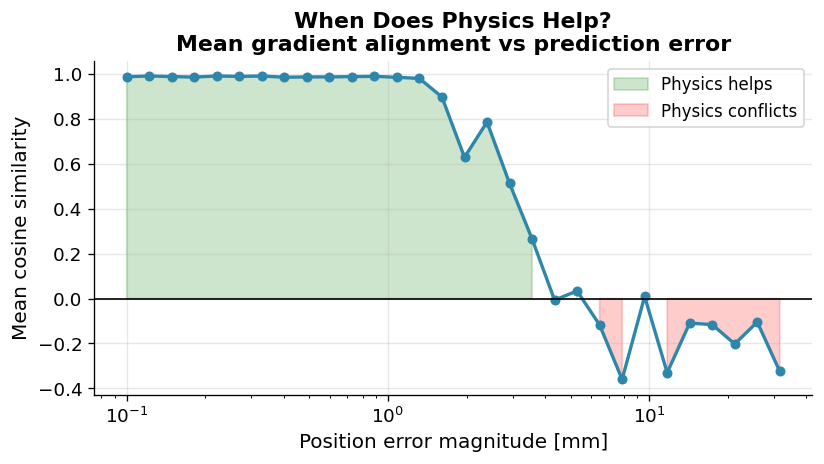

Saved: diag_2b_cosine_vs_error.png


In [11]:
# Summary: mean cosine similarity vs error magnitude
error_range = np.logspace(-4, -1.5, 30)   # 0.1 mm to 30 mm
mean_cos = []

for err in error_range:
    cs = []
    for idx in indices[:20]:   # subset for speed
        true_pos = traj_lin[idx, :2]
        y_obs    = Y_lin[idx]
        pred_pos = true_pos + np.random.randn(2) * err
        g_p = grad_pos(pred_pos, true_pos)
        g_ph= grad_phys(pred_pos, y_obs)
        cs.append(cosine_sim(g_p, g_ph))
    mean_cos.append(np.mean(cs))

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(error_range*1e3, mean_cos, 'o-', color='#2E86AB',
            linewidth=2, markersize=5)
ax.axhline(0, color='black', linewidth=1)
ax.fill_between(error_range*1e3, mean_cos, 0,
                where=np.array(mean_cos) > 0,
                alpha=0.2, color='green', label='Physics helps')
ax.fill_between(error_range*1e3, mean_cos, 0,
                where=np.array(mean_cos) < 0,
                alpha=0.2, color='red', label='Physics conflicts')
ax.set_xlabel('Position error magnitude [mm]', fontsize=12)
ax.set_ylabel('Mean cosine similarity', fontsize=12)
ax.set_title('When Does Physics Help?\n'
             'Mean gradient alignment vs prediction error',
             fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('diag_2b_cosine_vs_error.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: diag_2b_cosine_vs_error.png')

---
## 3 · PCA of Signal Space

**What it shows.** Project the high-dimensional complex array responses $\mathbf{y}(t) \in \mathbb{C}^{49}$ (treated as $\mathbb{R}^{98}$) down to 2D via PCA. Colour each point by the true finger $x$-position, $y$-position, and trajectory type.

**What to look for.**
- **Smooth colour gradients in 2D PCA space** → nearby positions produce similar signals, and far positions produce different signals. The signal space is geometrically well-organised. A linear model could work.
- **Tangled or overlapping colour regions** → the PCA projection does not separate positions well. Nonlinear methods (MLP, t-SNE) are needed.
- **Explained variance ratio** → how much information the first two components capture. Below 50% means significant structure is lost in 2D.

Also shown: the variance explained curve, which tells you how many PCA components you need to capture 90% and 99% of the signal variance. This directly sets the minimum useful input dimensionality for any model.

In [12]:
# Build feature matrix: [Re(Y), Im(Y)] normalised
def prepare_features(Y):
    X = np.concatenate([np.real(Y), np.imag(Y)], axis=1)
    return X / (np.mean(np.abs(X)) + 1e-12)

X_all = prepare_features(Y_all)   # (3N, 2S)

# Fit PCA
pca = PCA(n_components=min(50, X_all.shape[0]-1))
X_pca_full = pca.fit_transform(X_all)
X_pca2 = X_pca_full[:, :2]

print(f'PCA fitted on {X_all.shape}')
print(f'Explained variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%  '
      f'PC2={pca.explained_variance_ratio_[1]*100:.1f}%  '
      f'Total (2 PCs)={pca.explained_variance_ratio_[:2].sum()*100:.1f}%')
cumvar = np.cumsum(pca.explained_variance_ratio_)
n90 = np.searchsorted(cumvar, 0.90) + 1
n99 = np.searchsorted(cumvar, 0.99) + 1
print(f'Components for 90% variance: {n90}  |  99%: {n99}')

PCA fitted on (600, 98)
Explained variance: PC1=6.8%  PC2=5.9%  Total (2 PCs)=12.7%
Components for 90% variance: 39  |  99%: 51


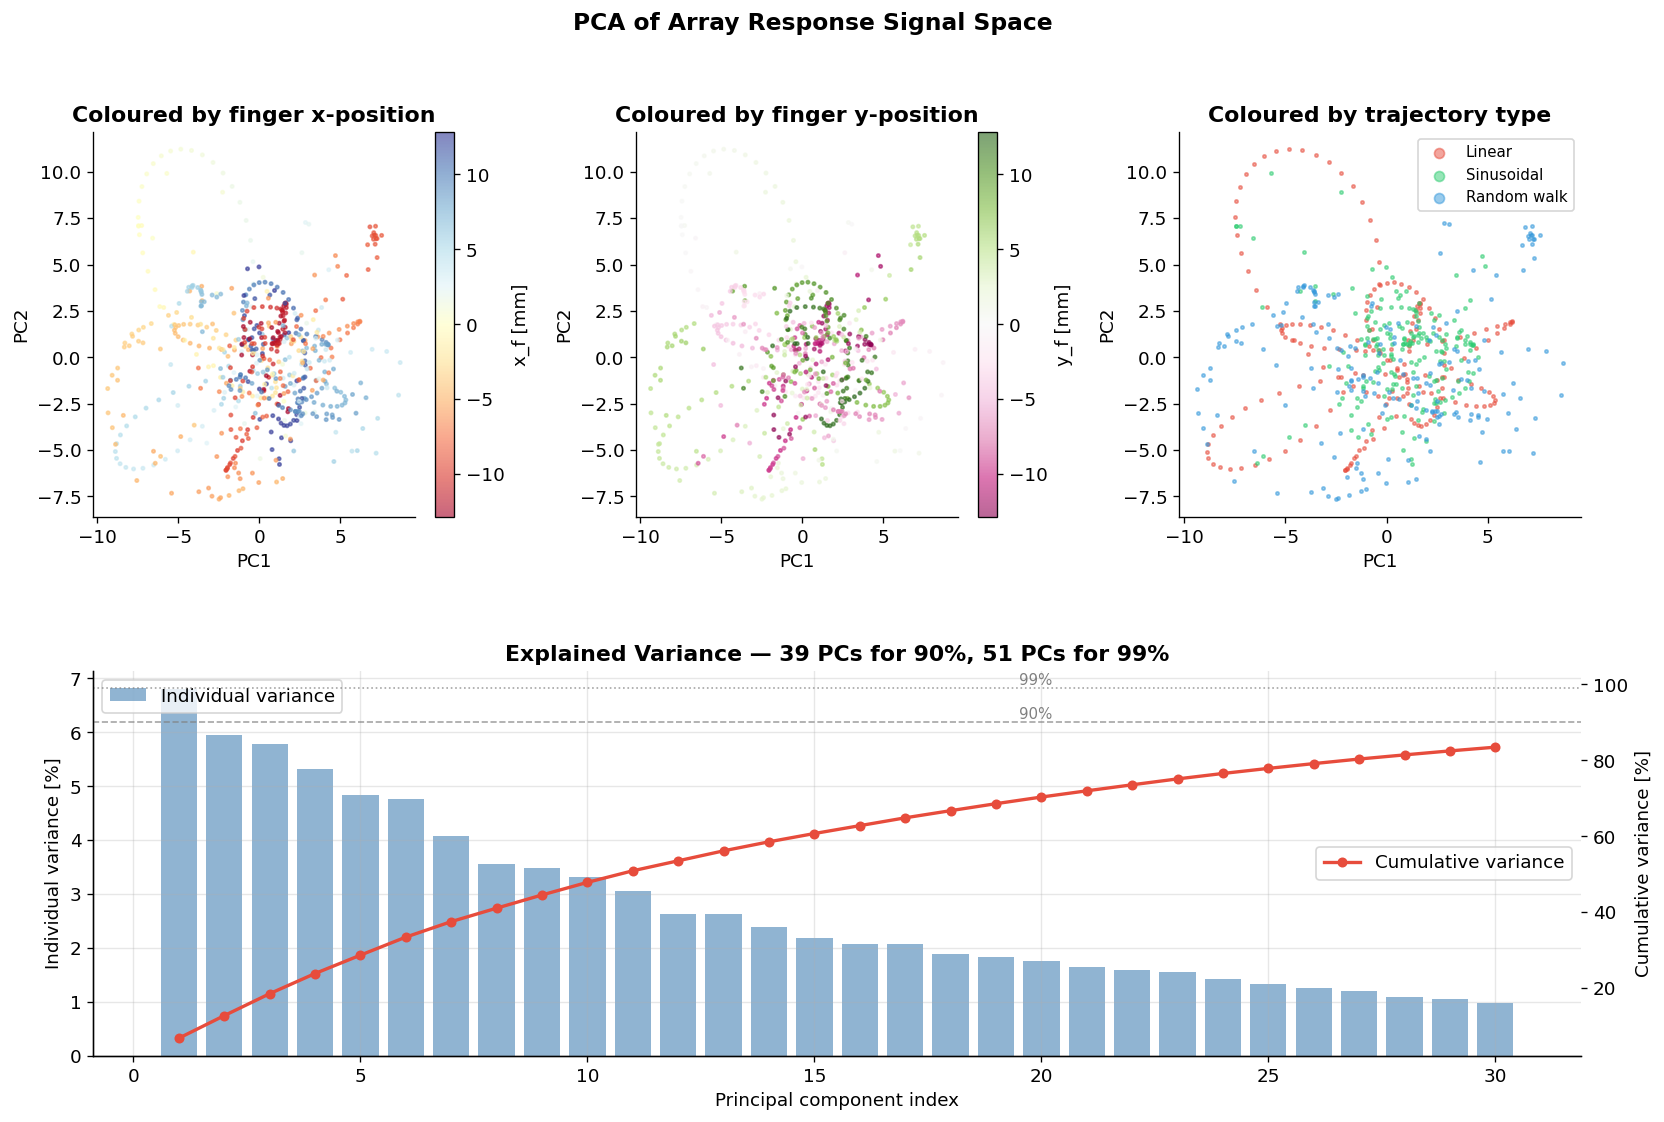

Saved: diag_3_pca.png


In [13]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# -- Panel 1: colour by x_f --
ax = fig.add_subplot(gs[0, 0])
sc = ax.scatter(X_pca2[:,0], X_pca2[:,1], c=P_all[:,0]*1e3,
                cmap='RdYlBu', s=4, alpha=0.6)
ax.set_title('Coloured by finger x-position', fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.colorbar(sc, ax=ax, label='x_f [mm]')

# -- Panel 2: colour by y_f --
ax = fig.add_subplot(gs[0, 1])
sc = ax.scatter(X_pca2[:,0], X_pca2[:,1], c=P_all[:,1]*1e3,
                cmap='PiYG', s=4, alpha=0.6)
ax.set_title('Coloured by finger y-position', fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.colorbar(sc, ax=ax, label='y_f [mm]')

# -- Panel 3: colour by trajectory type --
ax = fig.add_subplot(gs[0, 2])
traj_colors = {0: '#E74C3C', 1: '#2ECC71', 2: '#3498DB'}
traj_names  = {0: 'Linear', 1: 'Sinusoidal', 2: 'Random walk'}
for t in [0,1,2]:
    mask = labels == t
    ax.scatter(X_pca2[mask,0], X_pca2[mask,1],
               c=traj_colors[t], s=4, alpha=0.5,
               label=traj_names[t])
ax.set_title('Coloured by trajectory type', fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(markerscale=3, fontsize=9)

# -- Panel 4: explained variance curve --
ax = fig.add_subplot(gs[1, :])
n_show = min(30, len(pca.explained_variance_ratio_))
cumvar_show = np.cumsum(pca.explained_variance_ratio_[:n_show]) * 100
indvar_show = pca.explained_variance_ratio_[:n_show] * 100
ax2 = ax.twinx()
ax.bar(range(1, n_show+1), indvar_show,
       color='steelblue', alpha=0.6, label='Individual variance')
ax2.plot(range(1, n_show+1), cumvar_show,
         'o-', color='#E74C3C', linewidth=2, markersize=5,
         label='Cumulative variance')
ax2.axhline(90, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax2.axhline(99, color='gray', linestyle=':',  linewidth=1, alpha=0.7)
ax2.text(n_show*0.65, 91, '90%', color='gray', fontsize=9)
ax2.text(n_show*0.65, 100, '99%', color='gray', fontsize=9)
ax.set_xlabel('Principal component index', fontsize=11)
ax.set_ylabel('Individual variance [%]', fontsize=11)
ax2.set_ylabel('Cumulative variance [%]', fontsize=11)
ax.set_title(f'Explained Variance — {n90} PCs for 90%, {n99} PCs for 99%',
             fontweight='bold')
ax.legend(loc='upper left'); ax2.legend(loc='center right')
ax.grid(True, alpha=0.3)

plt.suptitle('PCA of Array Response Signal Space', fontsize=14, fontweight='bold')
plt.savefig('diag_3_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: diag_3_pca.png')

---
## 4 · t-SNE of Signal Space

**What it shows.** t-SNE preserves local neighbourhood structure in 2D. Points that are close in the original 98-dimensional signal space are placed close together in 2D, regardless of global structure.

**What to look for.**
- **Smooth colour gradients** → the signal space has good local discriminability. Even a nearest-neighbour classifier in signal space would localise well.
- **Cluster boundaries that align with position changes** → finger position is the dominant source of variance in the signal. Other sources (noise, trajectory history) are secondary.
- **Compare PCA vs t-SNE** → if t-SNE shows cleaner gradients than PCA, the signal-to-position mapping is nonlinear. This justifies using a nonlinear model (MLP, PINN) over a linear one.

⚠️ t-SNE is stochastic and slow. Run on a subsample (500 points) for speed. Adjust `n_subsample` if you want more points.

In [14]:
n_subsample = 500   # increase for more detail, decrease for speed
idx_sub = np.random.choice(len(X_all), size=n_subsample, replace=False)
X_sub   = X_all[idx_sub]
P_sub   = P_all[idx_sub]
L_sub   = labels[idx_sub]

print(f'Running t-SNE on {n_subsample} samples...')
tsne   = TSNE(n_components=2, perplexity=30, random_state=42,
              max_iter=1000, learning_rate='auto', init='pca')
X_tsne = tsne.fit_transform(X_sub)
print(f't-SNE done. KL divergence: {tsne.kl_divergence_:.4f}')

Running t-SNE on 500 samples...
t-SNE done. KL divergence: 0.5821


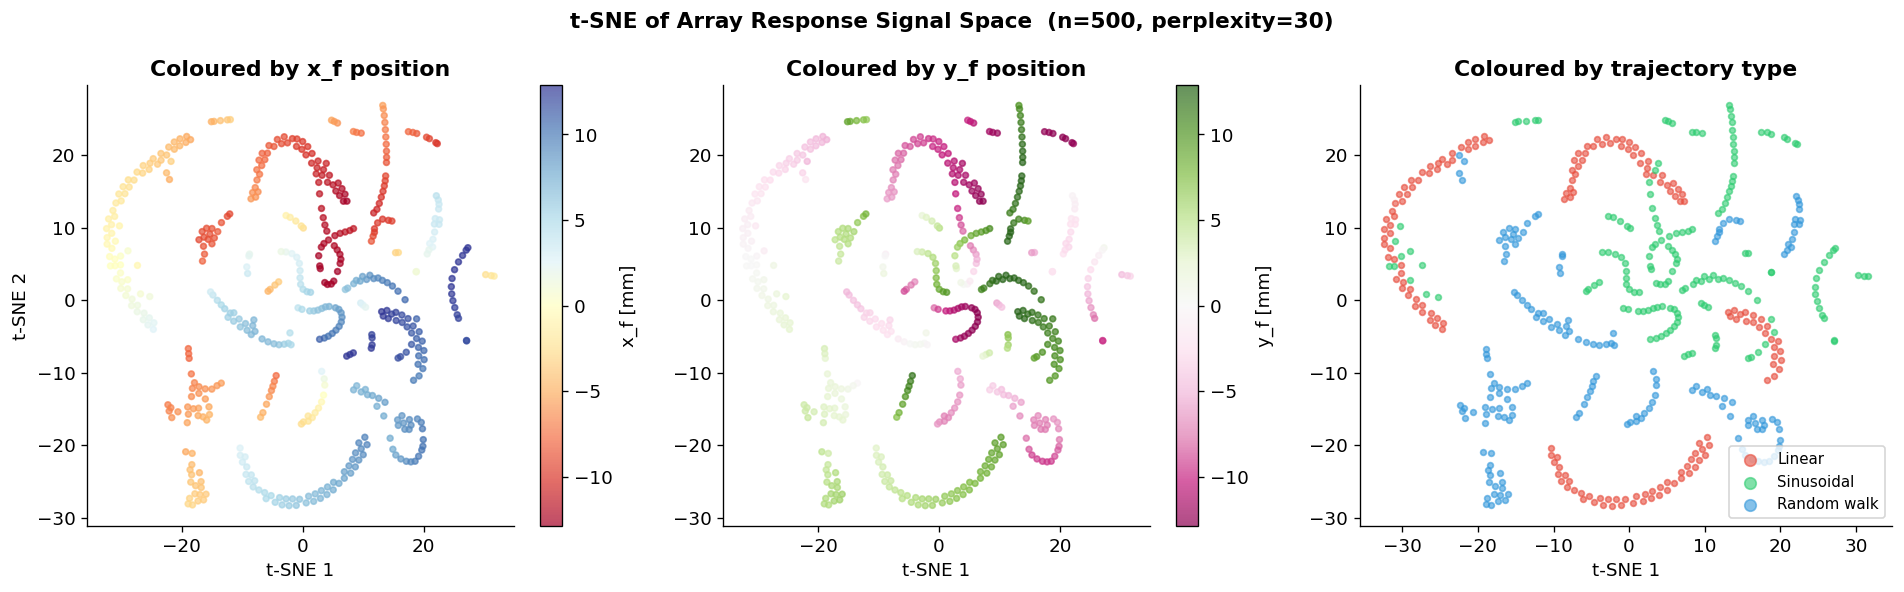

Saved: diag_4_tsne.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Colour by x_f
sc = axes[0].scatter(X_tsne[:,0], X_tsne[:,1], c=P_sub[:,0]*1e3,
                     cmap='RdYlBu', s=12, alpha=0.7)
axes[0].set_title('Coloured by x_f position', fontweight='bold')
axes[0].set_xlabel('t-SNE 1'); axes[0].set_ylabel('t-SNE 2')
plt.colorbar(sc, ax=axes[0], label='x_f [mm]')

# Colour by y_f
sc = axes[1].scatter(X_tsne[:,0], X_tsne[:,1], c=P_sub[:,1]*1e3,
                     cmap='PiYG', s=12, alpha=0.7)
axes[1].set_title('Coloured by y_f position', fontweight='bold')
axes[1].set_xlabel('t-SNE 1')
plt.colorbar(sc, ax=axes[1], label='y_f [mm]')

# Colour by trajectory type
for t in [0,1,2]:
    mask = L_sub == t
    axes[2].scatter(X_tsne[mask,0], X_tsne[mask,1],
                    c=traj_colors[t], s=12, alpha=0.6,
                    label=traj_names[t])
axes[2].set_title('Coloured by trajectory type', fontweight='bold')
axes[2].set_xlabel('t-SNE 1')
axes[2].legend(markerscale=2, fontsize=9)

plt.suptitle(f't-SNE of Array Response Signal Space  '
             f'(n={n_subsample}, perplexity=30)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('diag_4_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: diag_4_tsne.png')

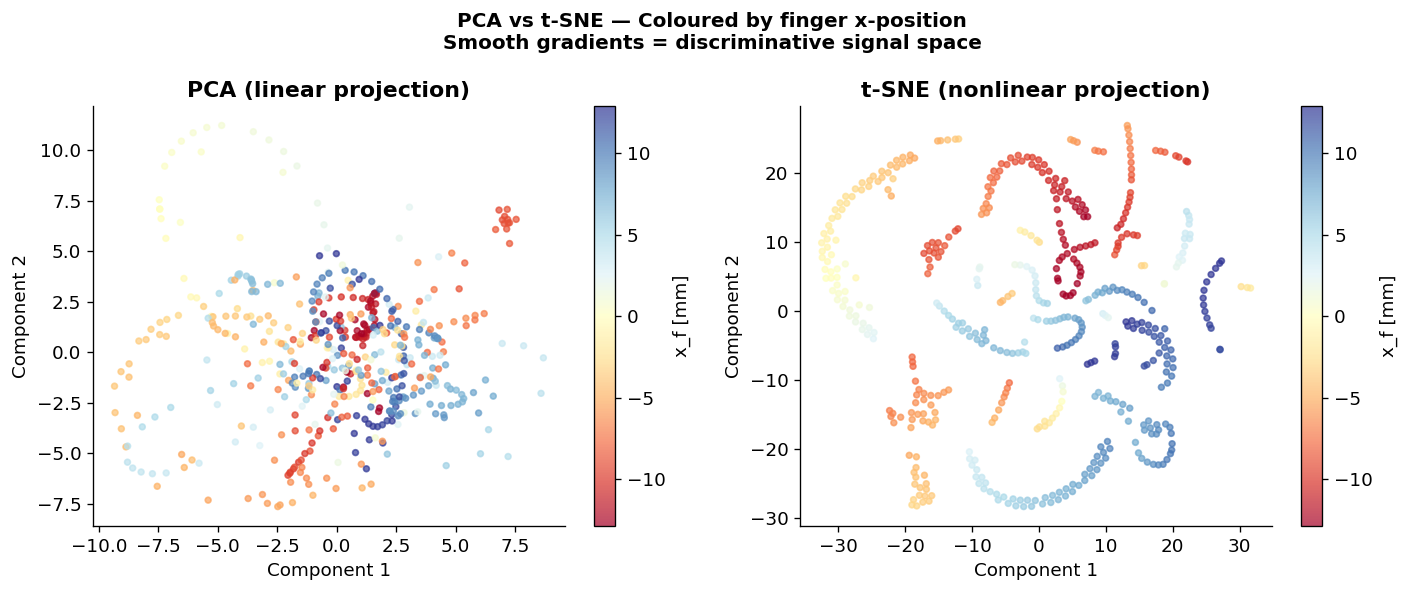

Saved: diag_4b_pca_vs_tsne.png


In [16]:
# PCA vs t-SNE side-by-side comparison for x_f (most compact summary)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, X_proj, title in [
    (axes[0], X_pca2[idx_sub],  'PCA (linear projection)'),
    (axes[1], X_tsne,           't-SNE (nonlinear projection)'),
]:
    sc = ax.scatter(X_proj[:,0], X_proj[:,1], c=P_sub[:,0]*1e3,
                    cmap='RdYlBu', s=12, alpha=0.7)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Component 1'); ax.set_ylabel('Component 2')
    plt.colorbar(sc, ax=ax, label='x_f [mm]')

plt.suptitle('PCA vs t-SNE — Coloured by finger x-position\n'
             'Smooth gradients = discriminative signal space',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('diag_4b_pca_vs_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: diag_4b_pca_vs_tsne.png')

---
## 5 · Re(y) and Im(y) as 7×7 Spatial Grids

**What it shows.** Reshape the complex array response back into the physical 7×7 grid and display Re(y) and Im(y) as spatial images at four time snapshots along the trajectory.

**What to look for.**
- **Smooth spatial variation** → a CNN with small (3×3) kernels will capture the dominant gradients. This justifies Improvement 1.
- **Sharp discontinuities or random-looking patterns** → the signal has no exploitable spatial structure. A flat FC network is fine; a CNN adds nothing.
- **The blockage dip** → in |y|, the element directly under the finger should show a local minimum (not maximum), because $\gamma_s$ attenuates the signal there. If you see this, the extended finger model is working correctly.
- **Phase rotation pattern** → Im(y) should show a sign flip across the finger position because phase shifts by $\sim\pi$ under the finger.

Also shown: |y| amplitude and phase $\angle y$, and a difference between point scatterer and extended finger to make the blockage effect visible.

In [18]:
# Noiseless versions for clean spatial patterns
Y_ext_noiseless, _, _ = simulate_extended(
    traj_lin, array_pos, k, sigma_f_phys,
    a_x, a_y, beta_min, phi_max, C, sigma_n2=0.0
)
Y_pt_noiseless = simulate(
    traj_lin, array_pos, 1.0, k, sigma_n2=0.0, C=C
)

snap_indices = [0, N//4, N//2, 3*N//4]
print(f'Visualising {len(snap_indices)} snapshots at '
      f'indices {snap_indices}')

Visualising 4 snapshots at indices [0, 50, 100, 150]


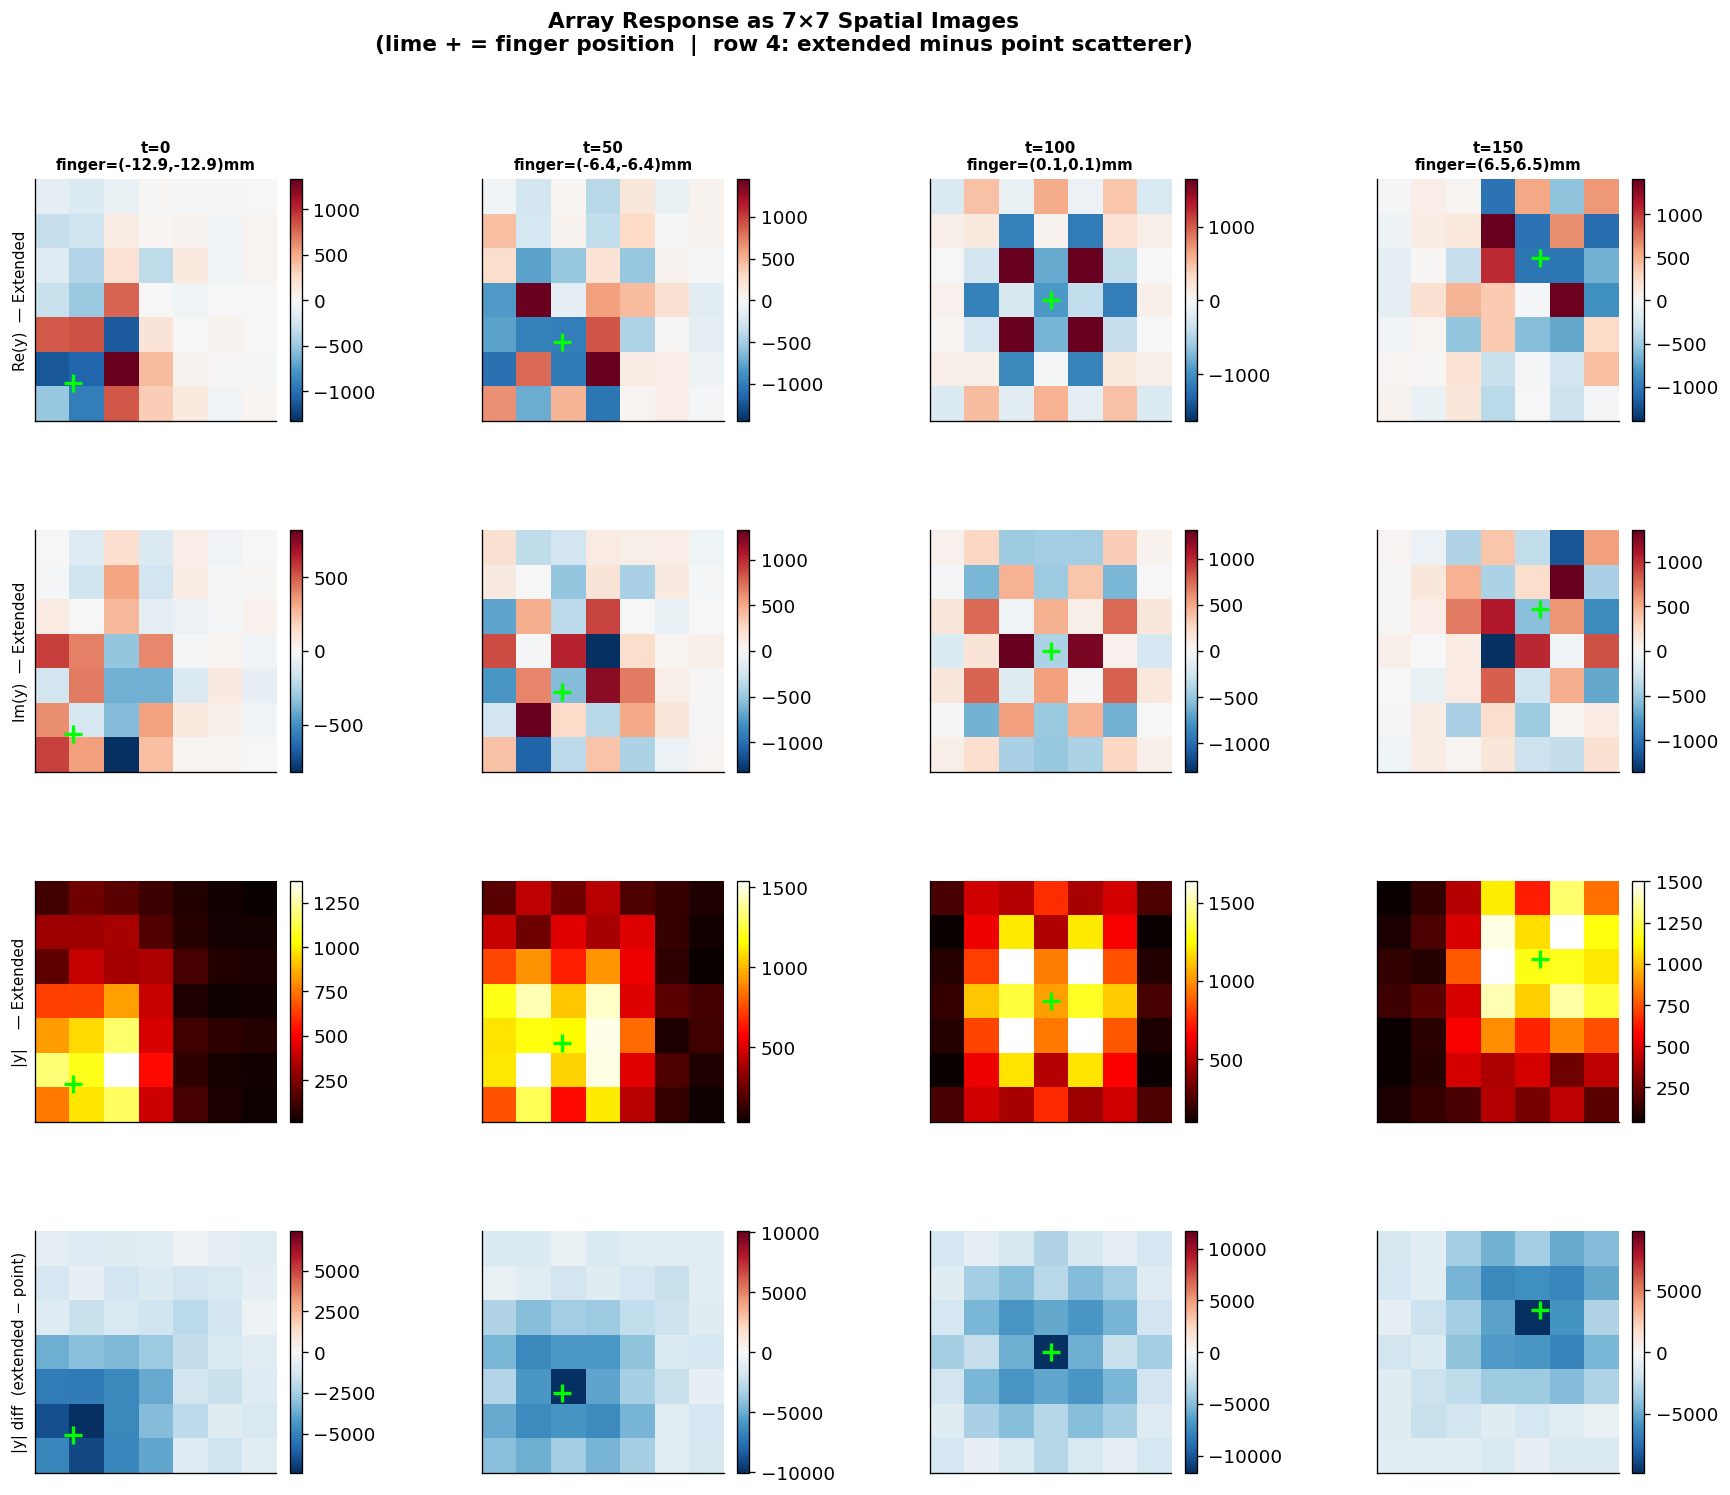

Saved: diag_5_spatial_grids.png


In [19]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(4, len(snap_indices), figure=fig,
                        hspace=0.45, wspace=0.35)
row_labels = ['Re(y)  — Extended', 'Im(y)  — Extended',
               '|y|    — Extended', '|y| diff  (extended − point)']
cmaps      = ['RdBu_r', 'RdBu_r', 'hot', 'RdBu_r']

for col, idx in enumerate(snap_indices):
    y_ext = Y_ext_noiseless[idx]
    y_pt  = Y_pt_noiseless[idx]
    fp    = traj_lin[idx, :2] * 1e3   # finger position in mm

    data_rows = [
        np.real(y_ext).reshape(Sx, Sy),
        np.imag(y_ext).reshape(Sx, Sy),
        np.abs(y_ext).reshape(Sx, Sy),
        (np.abs(y_ext) - np.abs(y_pt)).reshape(Sx, Sy),
    ]

    for row, (data, cmap) in enumerate(zip(data_rows, cmaps)):
        ax = fig.add_subplot(gs[row, col])

        if cmap == 'RdBu_r':
            v = np.abs(data).max()
            im = ax.imshow(data, cmap=cmap, origin='upper',
                           vmin=-v, vmax=v, aspect='equal')
        else:
            im = ax.imshow(data, cmap=cmap, origin='upper', aspect='equal')

        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # Mark finger position on array grid
        x_min_m, x_max_m, y_min_m, y_max_m = screen_bounds(Sx, Sy, de)
        col_f = (fp[0]/1e3 - x_min_m) / (x_max_m - x_min_m) * (Sy-1)
        row_f = (y_max_m - fp[1]/1e3) / (y_max_m - y_min_m) * (Sx-1)
        ax.scatter(col_f, row_f, s=120, color='lime', marker='+',
                   linewidths=2, zorder=5)

        # Column title (snapshot info)
        if row == 0:
            ax.set_title(f't={idx}\nfinger=({fp[0]:.1f},{fp[1]:.1f})mm',
                         fontsize=9, fontweight='bold')
        # Row label
        if col == 0:
            ax.set_ylabel(row_labels[row], fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Array Response as 7×7 Spatial Images\n'
             '(lime + = finger position  |  '
             'row 4: extended minus point scatterer)',
             fontsize=13, fontweight='bold')
plt.savefig('diag_5_spatial_grids.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: diag_5_spatial_grids.png')

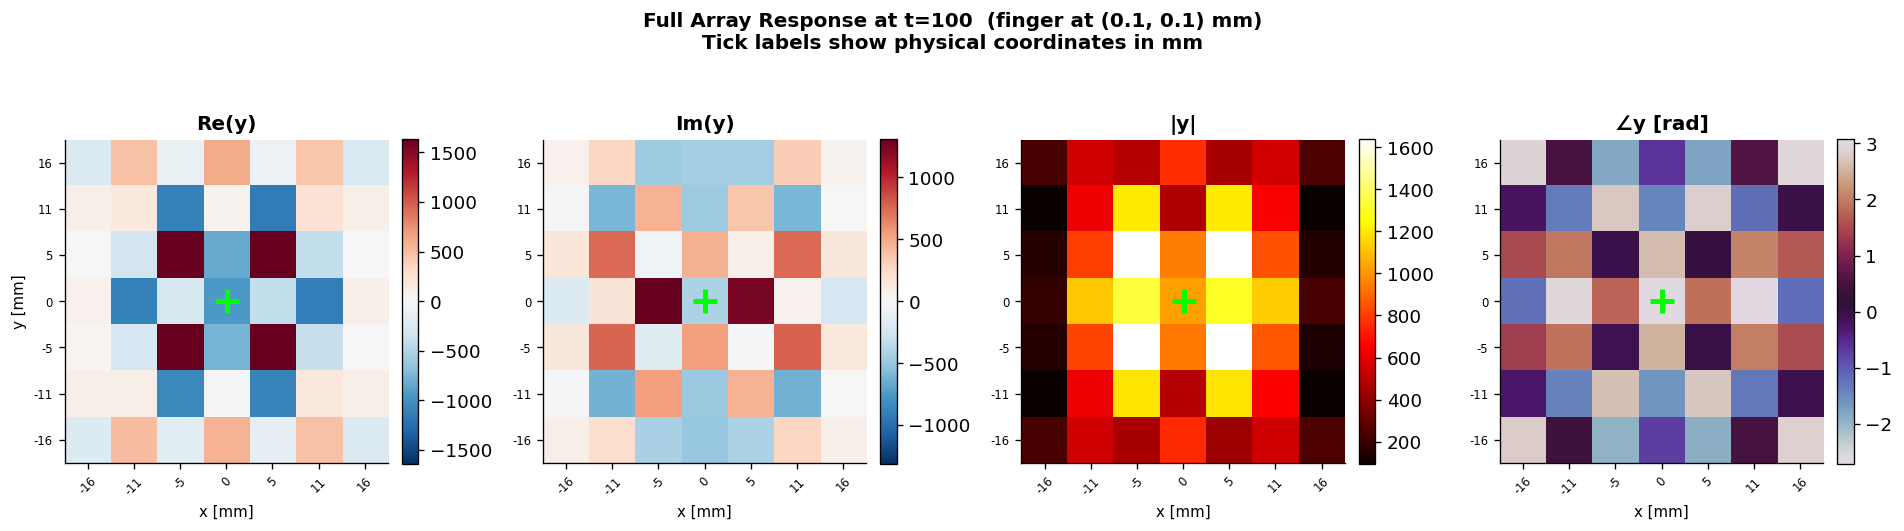

Saved: diag_5b_full_response_one_snapshot.png


In [20]:
# Zoomed comparison: Re(y), Im(y), |y|, and phase — all four at one snapshot
idx = N // 2
y   = Y_ext_noiseless[idx]
fp  = traj_lin[idx, :2] * 1e3

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
panels = [
    (np.real(y).reshape(Sx,Sy),  'Re(y)',    'RdBu_r'),
    (np.imag(y).reshape(Sx,Sy),  'Im(y)',    'RdBu_r'),
    (np.abs(y).reshape(Sx,Sy),   '|y|',      'hot'),
    (np.angle(y).reshape(Sx,Sy), '∠y [rad]', 'twilight'),
]

x_min_m, x_max_m, y_min_m, y_max_m = screen_bounds(Sx, Sy, de)
col_f = (fp[0]/1e3 - x_min_m) / (x_max_m - x_min_m) * (Sy-1)
row_f = (y_max_m - fp[1]/1e3) / (y_max_m - y_min_m) * (Sx-1)

for ax, (data, title, cmap) in zip(axes, panels):
    if cmap == 'RdBu_r':
        v = np.abs(data).max()
        im = ax.imshow(data, cmap=cmap, vmin=-v, vmax=v,
                       origin='upper', aspect='equal')
    else:
        im = ax.imshow(data, cmap=cmap, origin='upper', aspect='equal')
    ax.scatter(col_f, row_f, s=200, color='lime', marker='+',
               linewidths=3, zorder=5, label='Finger')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xticks(range(Sy))
    ax.set_yticks(range(Sx))
    ax.set_xticklabels([f'{(x_min_m + i*(x_max_m-x_min_m)/(Sy-1))*1e3:.0f}'
                        for i in range(Sy)], fontsize=7, rotation=45)
    ax.set_yticklabels([f'{(y_max_m - i*(y_max_m-y_min_m)/(Sx-1))*1e3:.0f}'
                        for i in range(Sx)], fontsize=7)
    ax.set_xlabel('x [mm]', fontsize=9)
    if ax == axes[0]: ax.set_ylabel('y [mm]', fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(f'Full Array Response at t={idx}  '
             f'(finger at ({fp[0]:.1f}, {fp[1]:.1f}) mm)\n'
             f'Tick labels show physical coordinates in mm',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('diag_5b_full_response_one_snapshot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: diag_5b_full_response_one_snapshot.png')

---
## Summary and Architecture Decision Guide

Use the results of the five diagnostics to fill in this table:

| Diagnostic | What you observed | Implication |
|---|---|---|
| 1. Physics landscape | Sharp/flat/multi-modal? | PINN reliable / needs curriculum / broken |
| 2. Gradient cosine | Positive at small errors? | Physics helps when network is close |
| 3. PCA variance | How many PCs for 90%? | Minimum input dimensionality needed |
| 4. t-SNE vs PCA | t-SNE cleaner? | Nonlinear model justified |
| 5. Spatial grids | Smooth patterns? | CNN justified |

**Decision rules:**
- If landscape is sharp → keep physics loss, tune $\lambda$
- If gradient cosine is negative at small errors → implement curriculum learning
- If t-SNE cleaner than PCA → MLP/CNN over linear model
- If spatial grids are smooth → CNN improvement worth implementing
- If PCA needs >20 components for 90% → flat FC may be hitting an information bottleneck; wider network needed